<a href="https://colab.research.google.com/github/Faseeh555/Internee-Performance-prediction-Model--Machine-Learing/blob/main/Intern_Performance_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Step 1: Importing the Required Libraries**

Machine Learning projects require different Python libraries, where each library has a specific purpose. Before we can build our model, we need to import these libraries so we can load the dataset, process the data, train machine learning algorithms, evaluate the model's performance, create visualizations, and save the trained model for future use.

In this project:

NumPy is imported to perform numerical operations and support mathematical computations.
Pandas is used to load and manipulate the intern performance dataset stored in a CSV file.
Matplotlib is used to create graphs and visualizations.
Seaborn is used to create attractive statistical plots that make the results easier to understand.
train_test_split divides the dataset into training and testing sets so that the model can be evaluated on unseen data.
RandomForestRegressor is the first machine learning algorithm used to predict the Performance Score of interns.
Regression evaluation metrics (MAE, MSE, and R² Score) are used to measure how accurately the model makes predictions.
XGBRegressor is another regression algorithm that will later be compared with Random Forest.
Joblib is used to save the trained machine learning model so it can be loaded and reused without training it again.

After importing these libraries, we will have all the necessary tools required to complete the entire machine learning project.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from xgboost import XGBRegressor
import joblib

**Step 2: Loading the Dataset**

After importing the required libraries, the next step is to load the dataset into Google Colab. The dataset is stored as a CSV (Comma-Separated Values) file, which is one of the most common file formats used in data analysis and machine learning.

To work with the dataset, we use the read_csv() function provided by the Pandas library. This function reads the CSV file and stores it in a DataFrame, which is a two-dimensional table consisting of rows and columns. A DataFrame makes it easy to view, analyze, and manipulate data using Python.

After loading the dataset, we use the head() function to display the first five rows. This allows us to quickly verify that the dataset has been loaded correctly and gives us an overview of the available columns and their values before performing any preprocessing or analysis.

In [2]:
data = pd.read_csv("intern_performance_regression_dataset_v2.csv")
data.head()

,Intern_ID,Tasks_Assigned,Tasks_Completed,Avg_Task_Time_Hours,Attendance_Percentage,Consistency_Score,Engagement_Score,Feedback_Score,Learning_Progress,Deadline_Misses,Performance_Score,Performance_Label
0,INT_0001,11,24,1.70,71.41,5.34,7.47,1.60,1.88,9,98.50,High
1,INT_0002,24,23,2.70,85.88,2.76,8.76,1.17,1.40,8,67.99,High
2,INT_0003,19,13,6.06,84.62,6.50,2.61,8.44,2.67,6,69.66,High
3,INT_0004,15,7,6.99,99.56,3.53,8.20,5.72,5.87,1,66.86,High
4,INT_0005,12,6,6.81,56.42,2.86,5.97,7.98,6.81,8,53.74,High


**Step 3: Checking and Removing Duplicate Records**

Before training a machine learning model, it is important to ensure that the dataset contains unique and reliable records. Duplicate rows can occur due to data entry mistakes, system errors, or when the same information is recorded more than once.

If duplicate records are present, the model may learn the same information repeatedly, which can introduce bias and reduce the quality of predictions. Therefore, checking for duplicates is an essential data preprocessing step.

In this step, we first count the total number of duplicate rows in the dataset. If duplicates are found, they are removed so that each intern is represented only once. This helps improve the quality and reliability of the dataset before training the machine learning model.

In [3]:
data.duplicated().sum()
data = data.drop_duplicates()

**Step 4: Separating Features (X) and Target Variable (y)**

Before training a machine learning model, we must divide the dataset into two parts:

Features (X): These are the input variables that the model uses to learn patterns and make predictions.
Target Variable (y): This is the output that the model is trained to predict.

In this project, the objective is to predict an intern's Performance Score. Therefore, Performance_Score becomes the target variable (y), while the remaining performance-related attributes become the input features (X).

Some columns are intentionally excluded from the feature set:

Intern_ID is a unique identifier assigned to each intern. It does not contain any information related to performance and therefore cannot help the model make predictions.
Performance_Score is removed because it is the value the model is trying to predict. Including it in the input features would allow the model to "see the answer," resulting in unrealistic and inaccurate training (this is called data leakage).
Performance_Label is also removed because it represents a categorical classification (such as Excellent, Average, or Poor), while this project focuses on predicting the numerical Performance Score using regression.

After separating the data, the first few rows of both X and y are displayed to verify that the features and target variable have been selected correctly.

In [4]:
X = data.drop(
    columns=[
        "Intern_ID",
        "Performance_Score",
        "Performance_Label"
    ]
)
y = data["Performance_Score"]
display(X.head())
display(y.head())

,Tasks_Assigned,Tasks_Completed,Avg_Task_Time_Hours,Attendance_Percentage,Consistency_Score,Engagement_Score,Feedback_Score,Learning_Progress,Deadline_Misses
0,11,24,1.70,71.41,5.34,7.47,1.60,1.88,9
1,24,23,2.70,85.88,2.76,8.76,1.17,1.40,8
2,19,13,6.06,84.62,6.50,2.61,8.44,2.67,6
3,15,7,6.99,99.56,3.53,8.20,5.72,5.87,1
4,12,6,6.81,56.42,2.86,5.97,7.98,6.81,8


,Performance_Score
0,98.50
1,67.99
2,69.66
3,66.86
4,53.74


**Step 5: Splitting the Dataset into Training and Testing Sets**

Before training a machine learning model, we divide the dataset into two separate parts:

Training Set: Used by the model to learn patterns and relationships between the input features and the target variable.
Testing Set: Used to evaluate how well the trained model performs on data it has never seen before.

This process helps us determine whether the model has actually learned meaningful patterns or has simply memorized the training data (a problem known as overfitting).

In this project, 80% of the dataset is used for training the model, while the remaining 20% is reserved for testing its performance.

To ensure that we obtain the same training and testing split every time the notebook is executed, we use random_state = 42. This makes the experiment reproducible, allowing anyone who runs the notebook to get the same results.

Finally, we display the shape of each dataset to verify that the data has been split correctly

In [5]:
X_train, X_test, y_train, y_test = train_test_split (
    X,
    y,
    test_size = 0.20,
    random_state= 42
)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(560, 9)
(140, 9)
(560,)
(140,)


**Step 6: Training the Random Forest Regression Model**

After preparing the training and testing datasets, the next step is to train the machine learning model.

In this project, we are using the Random Forest Regressor, which is an ensemble learning algorithm designed for regression problems. Instead of relying on a single Decision Tree, Random Forest builds multiple Decision Trees and combines their predictions to produce a more accurate and reliable result.

The model learns the relationship between the input features (such as task completion, attendance, feedback, and learning progress) and the target variable (Performance_Score). Once training is complete, the model can predict the performance score of interns whose data it has never seen before.

In this implementation, the model is configured to create 100 Decision Trees. The final prediction is obtained by averaging the predictions of all these trees, making Random Forest more robust and less likely to overfit compared to a single Decision Tree.

In [6]:
rf_model = RandomForestRegressor(
    n_estimators = 100,
    random_state =42
)
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

**Step 7: Making Predictions Using the Trained Model**

After training the Random Forest model, the next step is to use it to predict the Performance Score of interns in the testing dataset.

The testing data (X_test) contains only the input features of interns. Since the model has never seen these records during training, it uses the patterns it learned from the training data to estimate their Performance Scores.

The predicted values are stored in a new variable called y_pred. These predictions will later be compared with the actual Performance Scores (y_test) to evaluate how accurately the model performs.

For demonstration purposes, only the first 10 predicted scores are displayed.

In [7]:
y_pred = rf_model.predict(X_test)
print(y_pred[:10])

[52.3055 49.7053 39.9299 94.8992 91.9896 77.0571 97.4542 75.8914 59.9648
 80.5695]


**Step 8: Evaluating the Machine Learning Model**

After the model predicts the Performance Scores for the testing dataset, we need to measure how close these predicted values are to the actual Performance Scores.

To evaluate the performance of our Random Forest Regression model, we use four commonly used regression metrics:

Mean Absolute Error (MAE) – Measures the average prediction error.
Mean Squared Error (MSE) – Measures the average squared prediction error.
Root Mean Squared Error (RMSE) – Represents the prediction error in the original unit of the target variable.
R² Score (Coefficient of Determination) – Measures how well the model explains the variation in the target variable.

These metrics help us understand the accuracy and reliability of the trained model.

In [8]:
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("Mean absolute error: ", mae)
print("Mean squared error: ", mse)
print("Rooted mean absolute error: ", rmse)
print("R2 score: ", r2)

Mean absolute error:  3.5190921428571444
Mean squared error:  21.262677647071445
Rooted mean absolute error:  4.611147107507138
R2 score:  0.9359243416636194


**Step 9: Finding the Most Important Features**

After training the Random Forest model, we can analyze which input features influenced the model the most while predicting the Performance Score.

One of the advantages of the Random Forest algorithm is that it automatically calculates a feature importance score for each input feature during training.

Feature importance helps us understand:

Which factors had the greatest impact on predicting intern performance.
Which features contributed the least to the model.
Which variables might be the most valuable for future decision-making.

The importance values range from 0 to 1. In this project, we multiply them by 100 so they can be interpreted as percentages, making the results easier to read.

Finally, the features are sorted in descending order so that the most influential features appear at the top.

In [9]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_ *100
})
feature_importance = feature_importance.sort_values(
    by= "Importance",
    ascending= False
)
print("Feature Importance:\n ", feature_importance)

Feature Importance:
                   Feature  Importance
1        Tasks_Completed   53.257676
0         Tasks_Assigned   37.426511
6         Feedback_Score    2.886524
3  Attendance_Percentage    1.685519
4      Consistency_Score    1.417444
5       Engagement_Score    1.347546
7      Learning_Progress    0.890540
2    Avg_Task_Time_Hours    0.674303
8        Deadline_Misses    0.413938


**Step 10: Visualizing Feature Importance**

After calculating the feature importance values, it is helpful to visualize them using a bar chart. A graph makes it easier to compare the importance of different features than reading numerical values from a table.

In this project, we use the Seaborn library to create a horizontal bar chart, where:

The Y-axis represents the feature names.
The X-axis represents the importance score of each feature.
Longer bars indicate features that had a greater influence on predicting the Performance Score.

This visualization helps us quickly identify the most significant factors affecting intern performance.

<Figure size 1000x600 with 0 Axes>

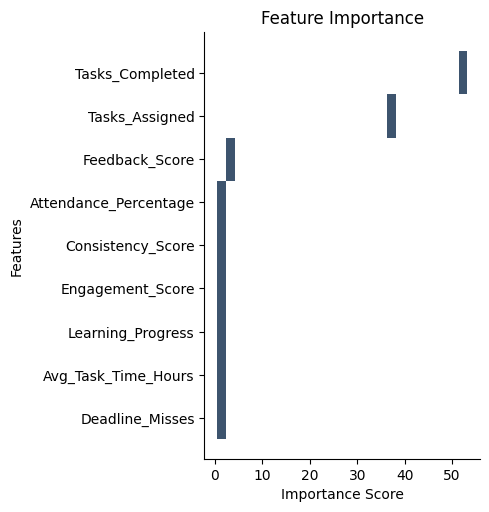

In [17]:
plt.figure(figsize=(10,6))
sns.displot(
    x = "Importance",
    y = "Feature",
    data= feature_importance
)
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

**Step 11: Predicting the Performance of a New Intern**

Once the machine learning model has been trained and evaluated, it can be used to predict the Performance Score of a new intern whose performance score is unknown.

To do this, we create a new DataFrame containing the intern's information. The feature names and their order must be exactly the same as those used during training. This ensures that the model correctly interprets the input data.

The trained Random Forest model then predicts the intern's Performance Score based on the provided features. Finally, the predicted score is categorized into one of three performance levels:

Likely to Excel (Score ≥ 80)
Average Performance (Score between 60 and 79.99)
May Need Support (Score < 60)

This demonstrates how the trained model can be applied in a real-world internship management system to identify interns who may excel or require additional guidance.

In [11]:
new_intern = pd.DataFrame(
    {
        "Tasks_Assigned": [20],
        "Tasks_Completed": [18],
        "Avg_Task_Time_Hours": [4.5],
       "Attendance_Percentage": [94],
        "Consistency_Score": [8.8],
        "Engagement_Score": [9.0],
       "Feedback_Score": [8.7],
        "Learning_Progress": [8.9],
        "Deadline_Misses": [1]
    }
)
predicted_score=rf_model.predict(new_intern)
print("Predicted Performance Score: ", predicted_score)
if predicted_score[0] >= 80:
    print("Prediction: Likely to Excel")
elif predicted_score[0] >= 60:
    print("Prediction: Average Performance")
else:
    print("Prediction: May Need Support")

Predicted Performance Score:  [80.7671]
Prediction: Likely to Excel


**Step 12: Saving the model.**

This joblib is a library to save a model and dump is a function to do so.

In [19]:
joblib.dump(rf_model, "rf_intern_performance_model.pkl")

['rf_intern_performance_model.pkl']

**Step 13: Downloading the saved model.**

This command is use to download the model saved by joblib.

In [13]:
from google.colab import files
files.download("rf_intern_performance_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>